# Generation Demo

Generate samples from a saved `ConditionalNodeFieldGraphGenerator`.

- inspect saved checkpoints
- load one model
- sample with and without feasibility filtering


In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import os
import random

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecules
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.12.0+cpu
CUDA available: False


In [6]:
import sys
import time
from types import MethodType

from sklearn.linear_model import SGDClassifier, SGDRegressor
from nsppk import NSPPK

from abstractgraph.operators import (
    add,
    combination,
    compose,
    connected_component,
    cycle,
    edge,
    filter_by_edge_label,
    merge,
    neighborhood,
    tree,
    unlabel,
)
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)

EDGE_GENERATIVE_SRC = Path('/home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-generative/src')
if not EDGE_GENERATIVE_SRC.exists():
    raise RuntimeError(f'abstractgraph-generative checkout not found at {EDGE_GENERATIVE_SRC}')
if str(EDGE_GENERATIVE_SRC) not in sys.path:
    sys.path.insert(0, str(EDGE_GENERATIVE_SRC))

from abstractgraph_generative.edge_generator import EdgeGenerator

def _find_early_stop_in_beam_any_phase(
    self,
    beam,
    *,
    scored,
    n_edges: int,
    target,
    target_lambda: float,
    fallback_index: int,
    graph_index: int,
    total_phases: int,
    start_time: float,
    verbose: bool,
):
    if not self.early_stop_if_final_feasible or not beam:
        return None

    current_states = self._score_current_beam_states_for_early_stop(
        beam,
        target=target,
        target_lambda=target_lambda,
        fallback_index=fallback_index,
    )
    if not current_states:
        return None

    best_current = current_states[0]
    best_expansion_score = None
    if scored['feasible_candidates']:
        best_expansion_score = scored['feasible_candidates'][0].get(
            'selection_score',
            scored['feasible_candidates'][0]['score'],
        )

    current_score = best_current.get('selection_score', best_current['score'])
    if best_expansion_score is not None and current_score < best_expansion_score:
        return None

    path = self._reconstruct_path(best_current)
    if verbose:
        elapsed_str = self._format_minutes_seconds(time.perf_counter() - start_time)
        current_edges = best_current['graph'].number_of_edges()
        edge_shortfall = max(0, n_edges - current_edges)
        print(
            f'[graph {graph_index}] early_stop fallback={fallback_index + 2}/{total_phases} '
            f"depth={best_current['depth']} max_depth={self.max_depth_} "
            f'edges={current_edges} edge_shortfall={edge_shortfall} remaining_edges=0 '
            f'tried={self.n_tried_} elapsed={elapsed_str} eta=0m 0.0s'
        )
        print(
            f'[graph {graph_index}] early_stop_selection_score='
            f"{current_score:.3f} best_expansion_selection_score="
            f'{self._format_optional_score(best_expansion_score)}'
        )
    return path

def repair_candidate_graphs(
    candidate_graphs,
    *,
    graph_generator,
    model_filename,
    notebook_data_root,
    random_seed,
    fallback_dataset='zinc_250k',
    store_per_size=256,
    n_neighbors=12,
    draw_graphs_fn=None,
    show_summary=True,
):
    if graph_generator.feasibility_estimator is None:
        raise RuntimeError('EdgeGenerator repair requires a fitted feasibility estimator.')

    sample_node_counts = sorted({graph.number_of_nodes() for graph in candidate_graphs})
    load_limit = max(1000, store_per_size * 4)
    edge_repair_dataset = model_filename.split('-', 1)[0]
    edge_repair_data_root = notebook_data_root / 'zinc'

    loader = ZINCLoader(root=edge_repair_data_root, on_error='skip')
    stored_counts = {node_count: 0 for node_count in sample_node_counts}
    edge_repair_graphs = []
    edge_repair_dataset_used = {}
    for node_count in sample_node_counts:
        selected_graphs = []
        for dataset_name in (edge_repair_dataset, fallback_dataset):
            candidate_store_graphs, _ = loader.load(
                dataset_name,
                limit=load_limit,
                min_node_count=node_count,
                max_node_count=node_count,
            )
            selected_graphs = candidate_store_graphs[:store_per_size]
            if selected_graphs:
                edge_repair_dataset_used[node_count] = dataset_name
                break
        edge_repair_graphs.extend(selected_graphs)
        stored_counts[node_count] = len(selected_graphs)

    missing_sizes = [node_count for node_count, count in stored_counts.items() if count == 0]
    if missing_sizes:
        raise RuntimeError(
            f'Could not load ZINC repair graphs for node counts: {missing_sizes} '
            f'from datasets {[edge_repair_dataset, fallback_dataset]}'
        )

    feasibility_kwargs = dict(
        nbits=19,
        parallel=True,
        backend='loky',
        n_jobs=-1,
    )

    partial_feasibility_estimators = [
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(neighborhood(radius=2), unlabel()),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=neighborhood(radius=1),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=cycle(), 
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(
                connected_component(),
                merge(use_edges=True),
                filter_by_edge_label(must_have_one_of=["aromatic"]),
                neighborhood(radius=1),
            ), 
            **feasibility_kwargs,
        ),
    ]
    partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

    final_feasibility_estimators = [
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(neighborhood(radius=2), unlabel()),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=neighborhood(radius=1),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(
                connected_component(),
                unlabel(),
                merge(use_edges=True),
                filter_by_edge_label(must_have_one_of=['aromatic']),
                edge(),
            ),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=cycle(),
            **feasibility_kwargs,
        ),
        FeasibilityEstimatorFeatureCannotExist(
            decomposition_function=compose(
                combination(number_of_elements=2, distance=0),
                cycle(),
                unlabel(),
            ),
            **feasibility_kwargs,
        ),
    ]
    final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)

    use_sparse_linear_mode = True
    vectorizer_kwargs = dict(
        radius=1,
        distance=4,
        connector=1,
        nbits=14,
        parallel=True,
    )

    graph_transformer = NSPPK(**vectorizer_kwargs, dense=not use_sparse_linear_mode)
    graph_estimator_model = SGDClassifier(
        loss='log_loss',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=random_seed,
        class_weight='balanced',
    )
    target_estimator_model = SGDRegressor(
        loss='epsilon_insensitive',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=random_seed,
    )
    edge_risk_estimator_model = SGDRegressor(
        loss='epsilon_insensitive',
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=random_seed,
    )

    graph_estimator = GraphEstimator(
        transformer=graph_transformer,
        estimator=graph_estimator_model,
    )
    target_estimator = None
    edge_risk_estimator = GraphEstimator(
        transformer=NSPPK(**vectorizer_kwargs, dense=not use_sparse_linear_mode),
        estimator=edge_risk_estimator_model,
    )

    edge_repair_generator = EdgeGenerator(
        partial_feasibility_estimator=partial_feasibility_estimator,
        final_feasibility_estimator=final_feasibility_estimator,
        graph_estimator=graph_estimator,
        target_estimator=target_estimator,
        edge_risk_estimator=edge_risk_estimator,
        target_estimator_mode='regression',
        decomposition_function=add(cycle(), tree()),
        enforce_diversity=False,
        n_negative_per_positive=5,
        n_replicates=5,
        beam_size=2,
        max_restarts=4,
        fit_n_jobs=-1,
        fit_backend='loky',
        edge_risk_lambda=0.25,
        verbose=True,
        seed=random_seed,
        early_stop_if_final_feasible=True,
        require_single_connected_component=True,
    )
    edge_repair_generator._find_early_stop_in_beam = MethodType(
        _find_early_stop_in_beam_any_phase,
        edge_repair_generator,
    )
    edge_repair_generator.store(edge_repair_graphs)

    if draw_graphs_fn is None:
        draw_graphs_fn = lambda graphs, **kwargs: display_graphs(
            graphs,
            n_graphs_per_line=7,
            **kwargs,
        )

    sample_feasible = np.asarray(
        graph_generator.feasibility_estimator.predict(candidate_graphs),
        dtype=bool,
    )
    repaired_graphs = []
    for sample_idx, graph in enumerate(candidate_graphs):
        repaired_graph = edge_repair_generator.repair(
            graph,
            n_neighbors=min(n_neighbors, len(edge_repair_graphs)),
            draw_graphs_fn=draw_graphs_fn,
            return_path=False,
        )
        repaired_graphs.append(repaired_graph)
        print(
            f'sample {sample_idx}: nodes={graph.number_of_nodes()} edges={graph.number_of_edges()} '
            f'feasible_before={bool(sample_feasible[sample_idx])} repaired={repaired_graph is not None}'
        )

    valid_repaired_graphs = [graph for graph in repaired_graphs if graph is not None]
    repaired_feasible = None
    if valid_repaired_graphs:
        repaired_feasible = np.asarray(
            graph_generator.feasibility_estimator.predict(valid_repaired_graphs),
            dtype=bool,
        )

    if show_summary:
        if valid_repaired_graphs:
            print('edge_repair_dataset_used =', edge_repair_dataset_used)
            print('stored_counts =', stored_counts)
            print('repaired_feasible =', repaired_feasible.tolist())
            show_molecules(
                candidate_graphs,
                n=len(candidate_graphs),
                title='Raw samples before EdgeGenerator repair',
            )
            show_molecules(
                valid_repaired_graphs,
                n=len(valid_repaired_graphs),
                title='Raw samples after EdgeGenerator repair',
            )
        else:
            print('EdgeGenerator repair did not return any repaired samples.')

    return {
        'repaired_graphs': repaired_graphs,
        'valid_repaired_graphs': valid_repaired_graphs,
        'sample_feasible': sample_feasible,
        'repaired_feasible': repaired_feasible,
        'edge_repair_dataset_used': edge_repair_dataset_used,
        'stored_counts': stored_counts,
        'edge_repair_generator': edge_repair_generator,
        'edge_repair_graphs': edge_repair_graphs,
    }


In [7]:
#MODEL_FILENAME = 'zinc15-nonstreaming-d64-s0-99-b128-e350.pkl'
#MODEL_FILENAME = 'zinc15-streaming-d64-s0-5-w256-b8-e256.pkl'
#MODEL_FILENAME = 'zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl'
#MODEL_FILENAME = 'zinc20-nonstreaming-d64-s0-99-b128-e350.pkl'
MODEL_FILENAME = 'artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl'
N_SAMPLES = 1

DECODER_VERBOSE = 1
DECODER_EXISTENCE_THRESHOLD = 0.5
DECODER_ENFORCE_CONNECTIVITY = True
DECODER_DEGREE_SLACK_PENALTY = 1e6
DECODER_WARM_START_MST = True
DECODER_N_JOBS = -1
DECODER_GRAPH_RENDERER = draw_molecules

USE_FEASIBILITY_FILTERING = True
MAX_FEASIBILITY_ATTEMPTS = 5
FEASIBILITY_CANDIDATES_PER_ATTEMPT = 2
FEASIBILITY_FAILURE_MODE = 'return_partial'
MAX_FEASIBILITY_SECONDS_PER_SAMPLE = 10.0
FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT = 1
MAX_ORACLE_ITERATIONS = 4
ORACLE_USE_NODE_LABEL_CUTS = True
ORACLE_USE_EDGE_LABEL_CUTS = True
RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [8]:
list_saved_graph_generators(SAVED_GENERATOR_ROOT)

graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.verbose = DECODER_VERBOSE
graph_generator.graph_decoder.existence_threshold = DECODER_EXISTENCE_THRESHOLD
graph_generator.graph_decoder.enforce_connectivity = DECODER_ENFORCE_CONNECTIVITY
graph_generator.graph_decoder.degree_slack_penalty = DECODER_DEGREE_SLACK_PENALTY
graph_generator.graph_decoder.warm_start_mst = DECODER_WARM_START_MST
graph_generator.graph_decoder.n_jobs = DECODER_N_JOBS
graph_generator.graph_decoder.diagnostic_graph_renderer = DECODER_GRAPH_RENDERER
graph_generator.use_feasibility_filtering = USE_FEASIBILITY_FILTERING
graph_generator.max_feasibility_attempts = MAX_FEASIBILITY_ATTEMPTS
graph_generator.feasibility_candidates_per_attempt = FEASIBILITY_CANDIDATES_PER_ATTEMPT
graph_generator.feasibility_failure_mode = FEASIBILITY_FAILURE_MODE
graph_generator.max_feasibility_seconds_per_sample = MAX_FEASIBILITY_SECONDS_PER_SAMPLE
graph_generator.feasibility_oracle_candidates_per_attempt = FEASIBILITY_ORACLE_CANDIDATES_PER_ATTEMPT
graph_generator.max_oracle_iterations = MAX_ORACLE_ITERATIONS
graph_generator.oracle_use_node_label_cuts = ORACLE_USE_NODE_LABEL_CUTS
graph_generator.oracle_use_edge_label_cuts = ORACLE_USE_EDGE_LABEL_CUTS


,name,modified,size_mb
0,artificial-cycle-path-star-n1024-c-3-8-p-3-6-r...,2026-05-20 15:26,20.2
1,artificial-cycle-path-star-n512-c6-p3-r4x2-d64...,2026-05-20 12:02,12.1
2,zinc20-nonstreaming-d64-s0-99-b128-e350.pkl,2026-05-12 15:39,1087.7
3,zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl,2026-04-02 14:27,36.1
4,zinc15-nonstreaming-d64-s0-99-b128-e350.pkl,2026-04-02 14:27,176.1
5,zinc15-streaming-d64-s0-5-w256-b8-e256.pkl,2026-04-02 04:54,8.1
6,artificial-d32-n86-size8.pkl,2026-03-24 19:40,4.4


Loaded graph generator: artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl
/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators/artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350.pkl


In [9]:
print('Loaded graph generator =', getattr(graph_generator, 'model_name', MODEL_FILENAME))
print('Decoder verbose =', graph_generator.graph_decoder.verbose)
print('Decoder existence_threshold =', graph_generator.graph_decoder.existence_threshold)
print('Decoder enforce_connectivity =', graph_generator.graph_decoder.enforce_connectivity)
print('Decoder degree_slack_penalty =', graph_generator.graph_decoder.degree_slack_penalty)
print('Decoder warm_start_mst =', graph_generator.graph_decoder.warm_start_mst)
print('Decoder n_jobs =', graph_generator.graph_decoder.n_jobs)
print('Decoder graph renderer =', getattr(graph_generator.graph_decoder.diagnostic_graph_renderer, '__name__', graph_generator.graph_decoder.diagnostic_graph_renderer))
print('Feasibility estimator available =', graph_generator.feasibility_estimator is not None)
print('use_feasibility_filtering =', graph_generator.use_feasibility_filtering)
print('max_feasibility_attempts =', graph_generator.max_feasibility_attempts)
print('feasibility_candidates_per_attempt =', graph_generator.feasibility_candidates_per_attempt)
print('feasibility_failure_mode =', graph_generator.feasibility_failure_mode)
print('max_feasibility_seconds_per_sample =', graph_generator.max_feasibility_seconds_per_sample)
print('feasibility_oracle_candidates_per_attempt =', graph_generator.feasibility_oracle_candidates_per_attempt)
print('max_oracle_iterations =', graph_generator.max_oracle_iterations)
print('oracle_use_node_label_cuts =', graph_generator.oracle_use_node_label_cuts)
print('oracle_use_edge_label_cuts =', graph_generator.oracle_use_edge_label_cuts)


Loaded graph generator = artificial-cycle-path-star-n1024-c-3-8-p-3-6-r-2-4-x2-d64-b128-e350
Decoder verbose = 1
Decoder existence_threshold = 0.5
Decoder enforce_connectivity = True
Decoder degree_slack_penalty = 1000000.0
Decoder warm_start_mst = True
Decoder n_jobs = -1
Decoder graph renderer = draw_molecules
Feasibility estimator available = True
use_feasibility_filtering = True
max_feasibility_attempts = 5
feasibility_candidates_per_attempt = 2
feasibility_failure_mode = return_partial
max_feasibility_seconds_per_sample = 10.0
feasibility_oracle_candidates_per_attempt = 1
max_oracle_iterations = 4
oracle_use_node_label_cuts = True
oracle_use_edge_label_cuts = True


Sampling 1 graphs
generation of samples without feasibility filtering


MoleculeParseError: Unsupported bond label: 0

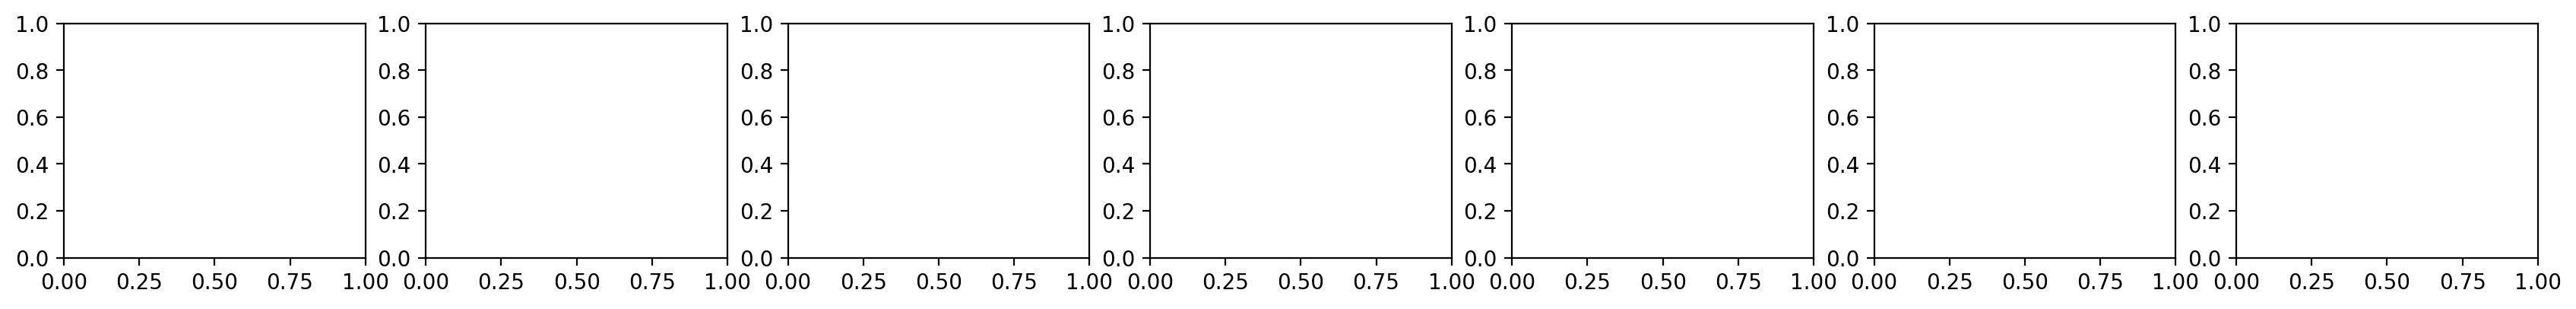

In [10]:
raw_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    apply_feasibility_filtering=False,
)
show_molecules(raw_samples, n=N_SAMPLES, title='generation of samples without feasibility filtering')


[repair] query_index=None n_neighbors=21 neighbor_indices=[108, 15, 27, 172, 9, 175, 203, 36, 136, 116, 174, 3, 32, 30, 207, 119, 123, 16, 58, 214, 171] neighbor_distances=[91.2305, 92.8493, 95.5615, 95.5981, 95.7601, 95.9427, 96.4417, 97.0206, 97.6012, 98.0102, 98.1377, 98.7573, 100.1449, 100.7869, 100.8712, 101.2571, 101.2571, 102.528, 102.5475, 102.5817, 103.0]


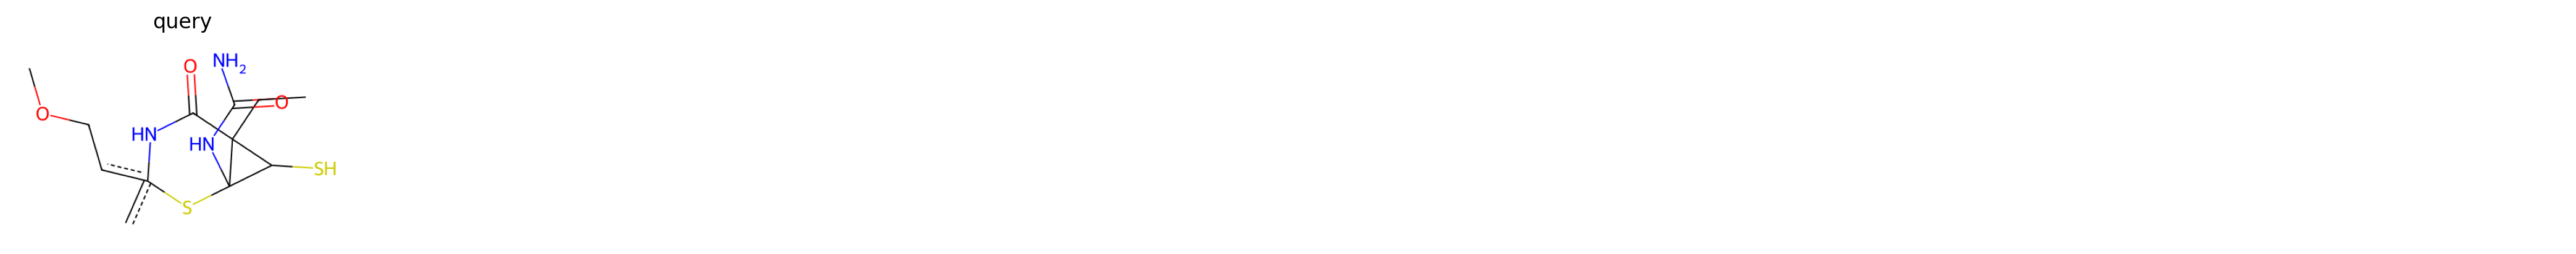

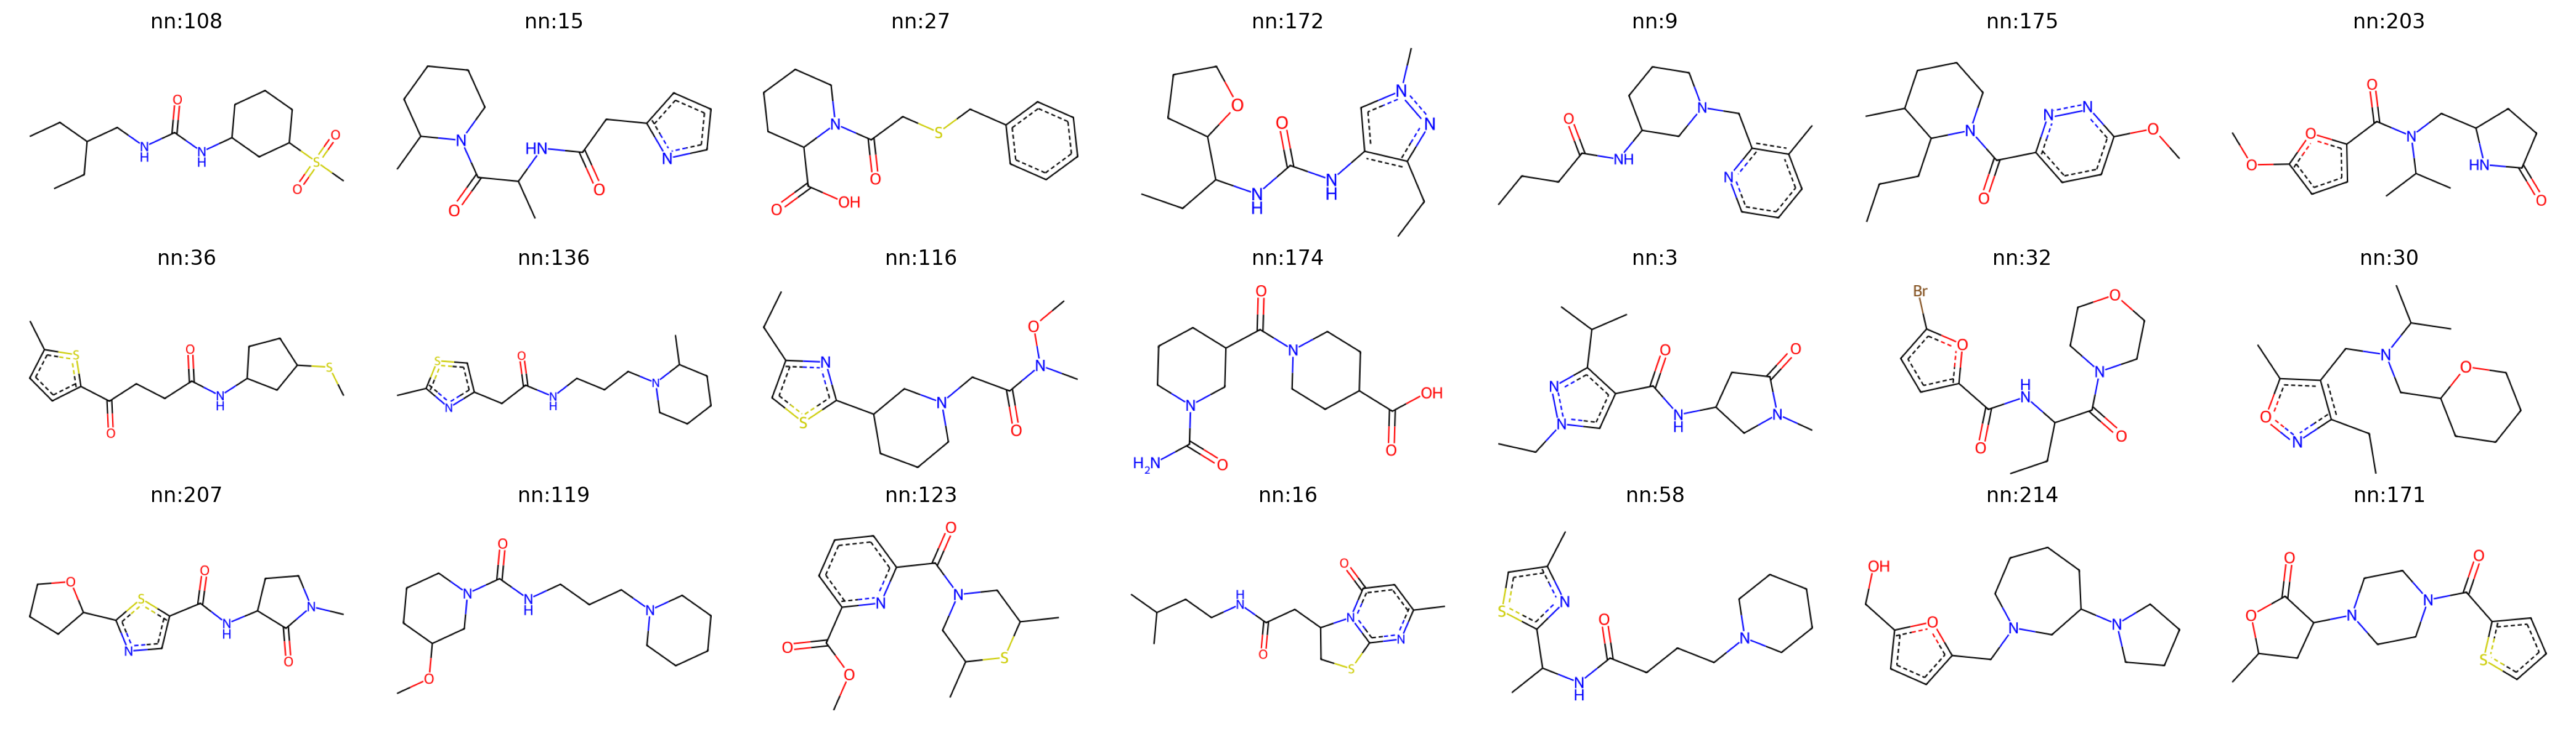

[fit] partial_feasibility_graphs=2132 positives=2215 negatives=10550 dataset=12765 partial_time=0m 10.9s
[fit] final_feasibility_graphs=21 final_time=0m 0.4s
[fit] lookahead_envelope_stages=22 lookahead_examples=2215 lookahead_rejection_model=lognormal_tail
[fit] graph_estimator_graphs=12765 positive_labels=2215 negative_labels=10550 time=0m 27.4s
[repair] attempt=1/4 original_edges=21 feasible_edges=16 target_edges=21 removed_edges=5


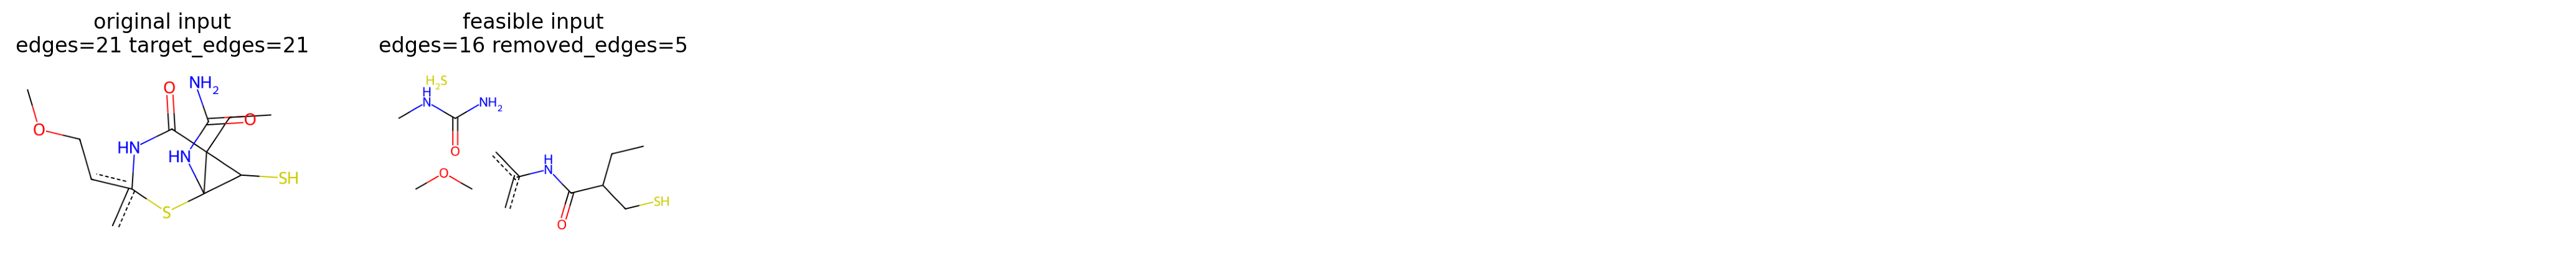

[graph 0] start start_edges=16 target_edges=21 remaining_edges=5


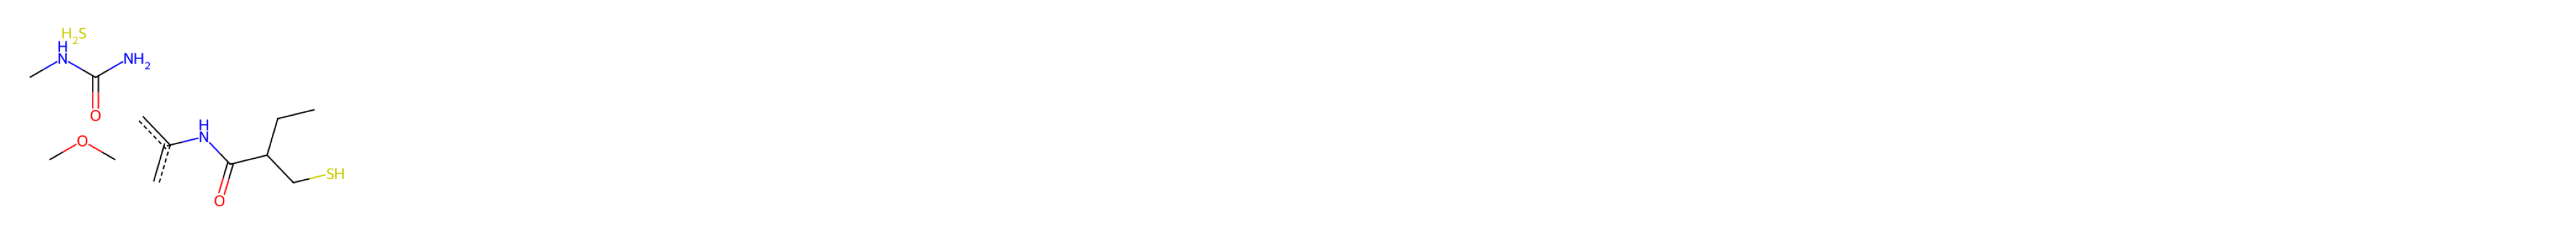

[graph 0] search_phase=1/5 beam_limit=2
[graph 0] remaining_edges=4
search_phase=1/5 depth=1 step_time=0m 27.7s eta=1m 50.7s
tried=522 generated=522 partial_infeasible=502 partial_feasible=20 viable=20 retained=2
best_score=0.000 best_risk=0.000
edge_risk_lambda=0.250 beam_limit=2


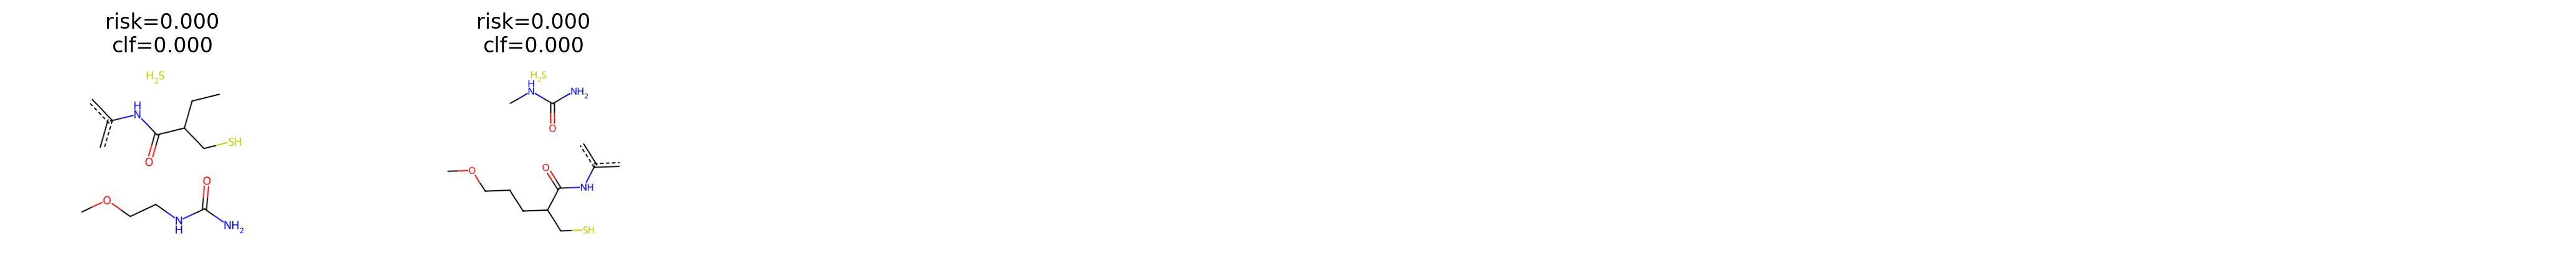

[graph 0] remaining_edges=3
search_phase=1/5 depth=2 step_time=0m 48.3s eta=2m 25.0s
tried=1560 generated=1038 partial_infeasible=1006 partial_feasible=32 viable=32 retained=2
best_score=0.000 best_risk=0.000
edge_risk_lambda=0.250 beam_limit=2


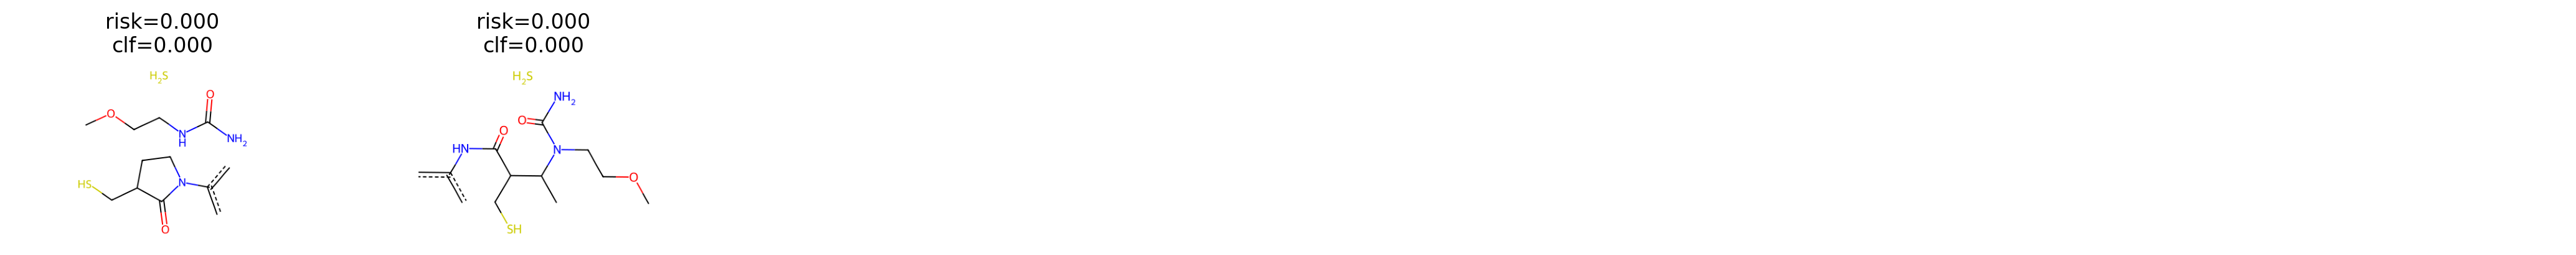

[graph 0] remaining_edges=2
search_phase=1/5 depth=3 step_time=0m 54.5s eta=1m 49.1s
tried=2592 generated=1032 partial_infeasible=1015 partial_feasible=17 viable=17 retained=2
best_score=0.000 best_risk=0.000
edge_risk_lambda=0.250 beam_limit=2


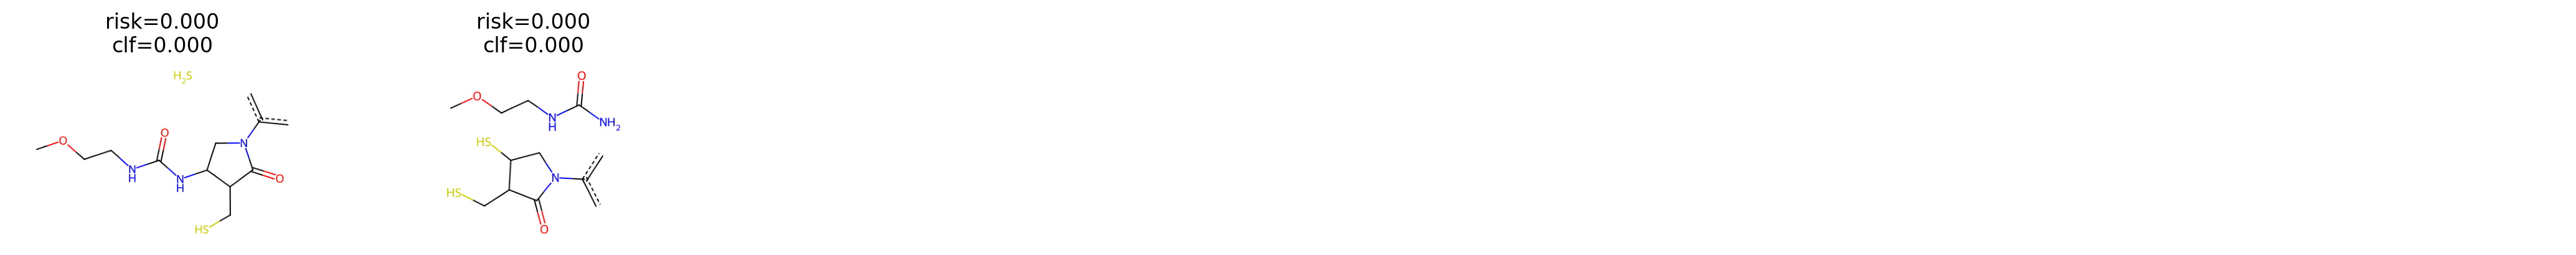

[graph 0] remaining_edges=1
search_phase=1/5 depth=4 step_time=0m 46.0s eta=0m 46.0s
tried=3618 generated=1026 partial_infeasible=1020 partial_feasible=6 viable=6 retained=2
best_score=0.000 best_risk=0.000
edge_risk_lambda=0.250 beam_limit=2


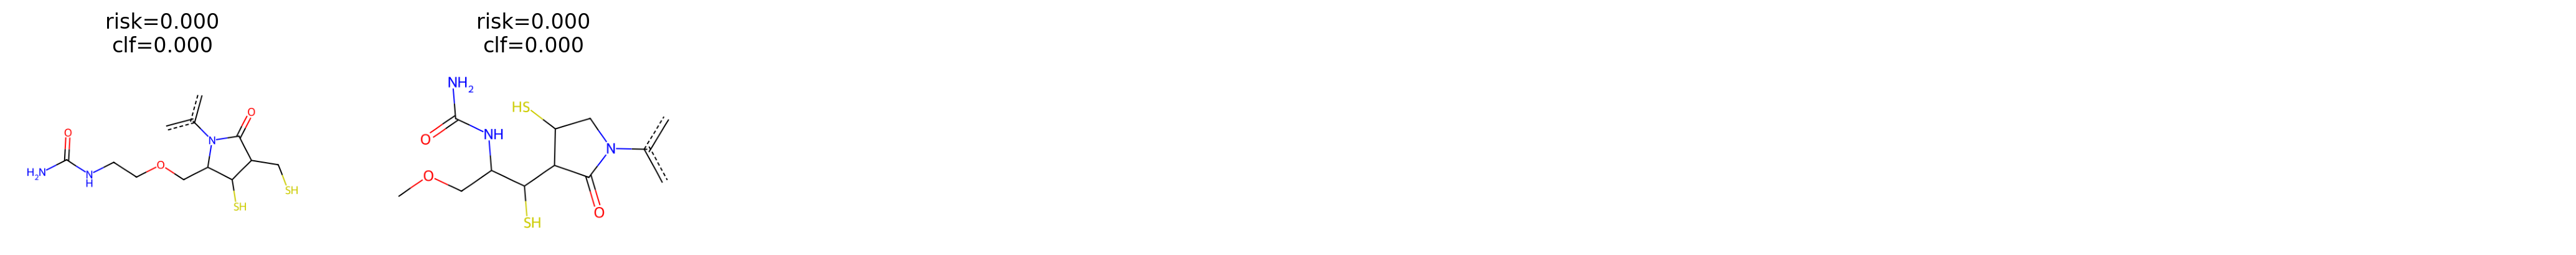

[graph 0] remaining_edges=0
search_phase=1/5 depth=5 step_time=1m 6.6s eta=0m 0.0s
tried=4638 generated=1020 partial_infeasible=1019 partial_feasible=1 viable=0 retained=0 final_infeasible=1
best_score=None best_risk=0.000
edge_risk_lambda=0.250 beam_limit=2
[graph 0] BACKTRACK no feasible candidates remain; 4 search phase(s) left
[edge_risk_fit] graphs=4633 training_set_size=4633 time=0m 29.0s
[graph 0] repair_fallback=1/4 rollback_steps=2 surgical_repairs=2 to_depth=2 beam_limit=3 edge_risk_training_set_size=4633 edge_risk_fit_time=0m 29.0s
[graph 0] surgical_removed_edges=['(14, 17),(5, 17)', '(14, 17),(1, 19)']
[graph 0] search_phase=2/5 beam_limit=3
[graph 0] remaining_edges=2
search_phase=2/5 depth=3 step_time=1m 34.7s eta=3m 9.4s
tried=5670 generated=1032 partial_infeasible=1020 partial_feasible=12 viable=12 retained=3
best_score=0.000 best_selection_score=-16.112 best_repulsion=0.981 best_risk=63.663
repulsion_lambda=0.200 edge_risk_lambda=0.250 beam_limit=3


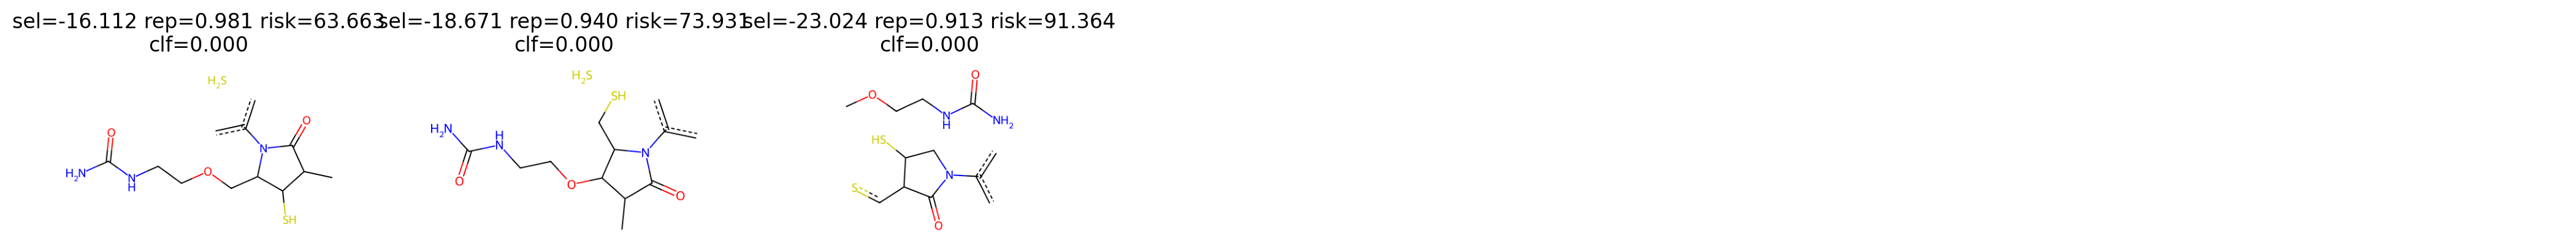

[graph 0] remaining_edges=1
search_phase=2/5 depth=4 step_time=1m 31.1s eta=1m 31.1s
tried=7209 generated=1539 partial_infeasible=1530 partial_feasible=9 lookahead_infeasible=3 viable=6 retained=3
best_score=0.000 best_selection_score=-17.406 best_repulsion=1.000 best_risk=68.823
repulsion_lambda=0.200 edge_risk_lambda=0.250 beam_limit=3


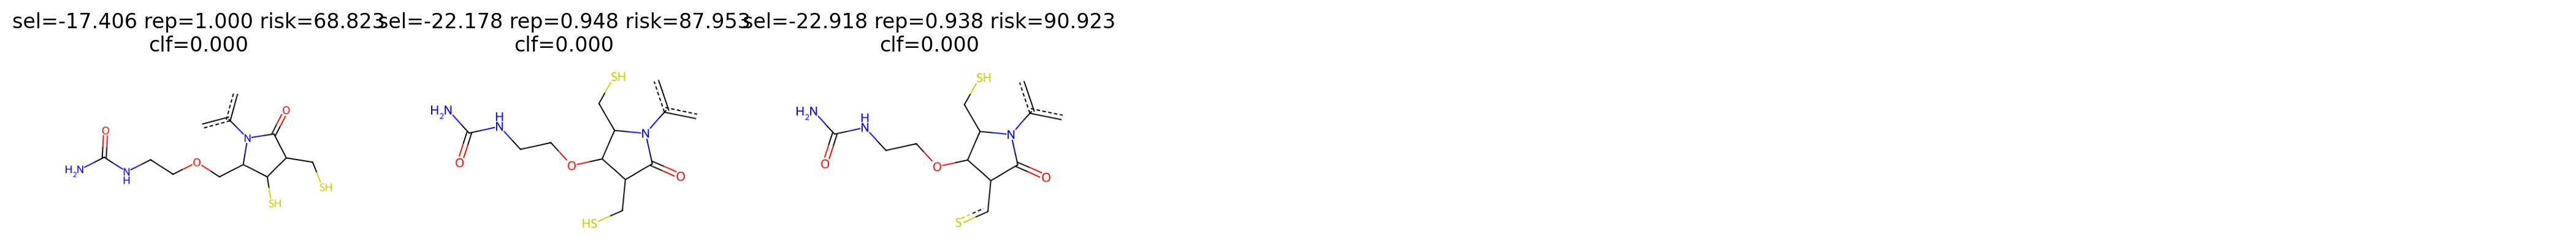

[graph 0] remaining_edges=0
search_phase=2/5 depth=5 step_time=1m 28.1s eta=0m 0.0s
tried=8739 generated=1530 partial_infeasible=1527 partial_feasible=3 viable=0 retained=0 final_infeasible=3
best_score=None best_risk=0.000
edge_risk_lambda=0.250 beam_limit=3
[graph 0] BACKTRACK no feasible candidates remain; 3 search phase(s) left
[edge_risk_fit] graphs=4098 training_set_size=8731 time=0m 28.6s
[graph 0] repair_fallback=2/4 rollback_steps=4 surgical_repairs=3 to_depth=0 beam_limit=5 edge_risk_training_set_size=8731 edge_risk_fit_time=0m 28.6s
[graph 0] surgical_removed_edges=['(3, 6),(3, 15),(1, 6),(0, 3)', '(3, 6),(3, 15),(0, 3),(1, 6)', '(3, 6),(0, 3),(1, 6),(3, 15)']
[graph 0] search_phase=3/5 beam_limit=5
[graph 0] remaining_edges=4
search_phase=3/5 depth=1 step_time=2m 3.4s eta=8m 13.6s
tried=10305 generated=1566 partial_infeasible=1440 partial_feasible=126 lookahead_infeasible=12 viable=114 retained=5
best_score=0.000 best_selection_score=-2.048 best_repulsion=0.874 best_risk=7.

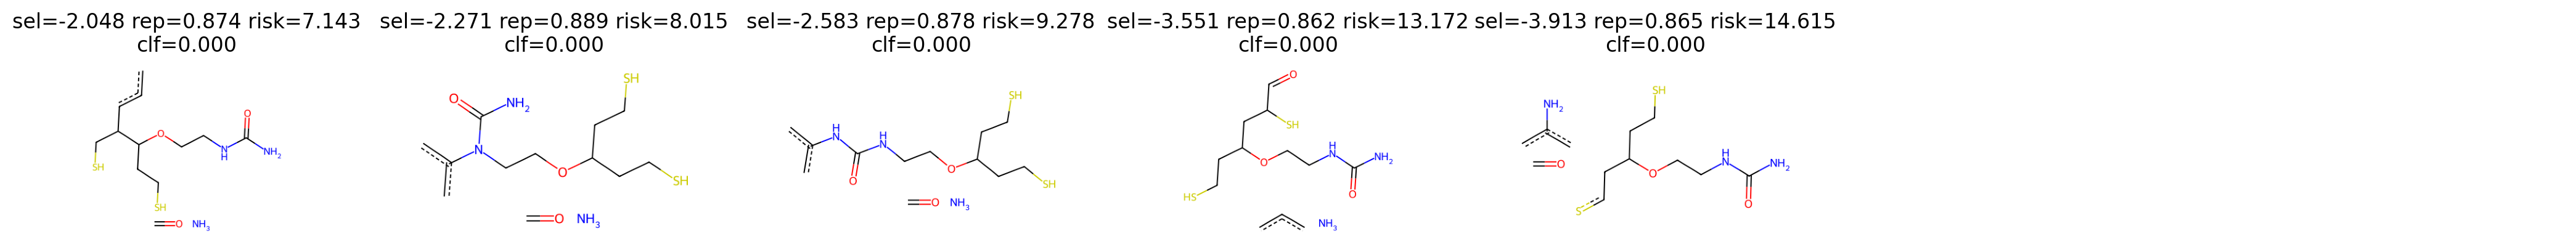

[graph 0] remaining_edges=3
search_phase=3/5 depth=2 step_time=2m 32.4s eta=7m 37.2s
tried=12900 generated=2595 partial_infeasible=2492 partial_feasible=103 viable=103 retained=5
best_score=0.000 best_selection_score=0.636 best_repulsion=0.868 best_risk=-3.586
repulsion_lambda=0.300 edge_risk_lambda=0.250 beam_limit=5


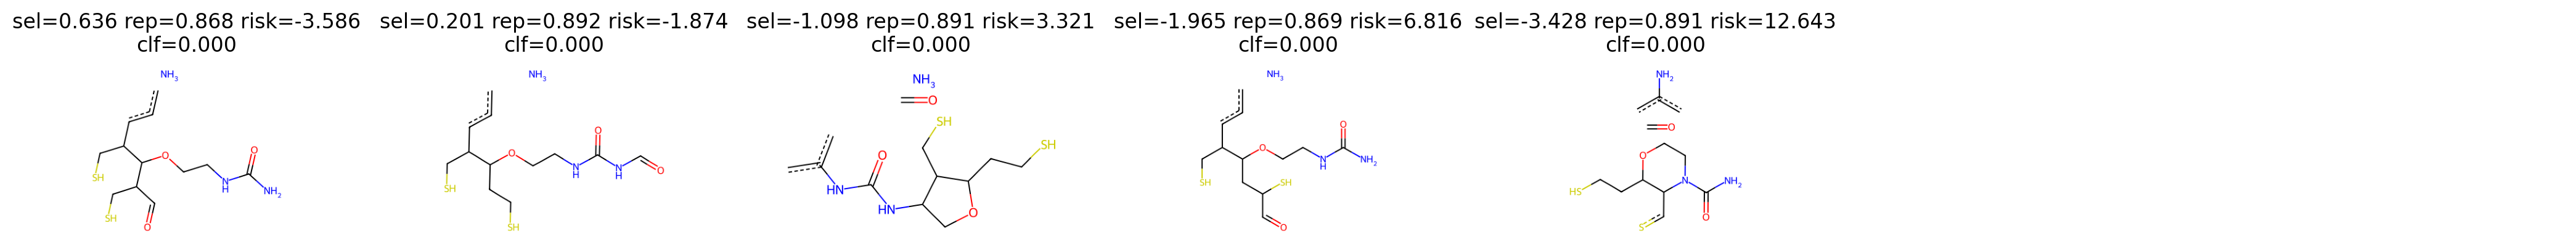

[graph 0] remaining_edges=2
search_phase=3/5 depth=3 step_time=2m 34.0s eta=5m 7.9s
tried=15480 generated=2580 partial_infeasible=2532 partial_feasible=48 lookahead_infeasible=1 viable=47 retained=5
best_score=0.000 best_selection_score=2.656 best_repulsion=0.894 best_risk=-11.697
repulsion_lambda=0.300 edge_risk_lambda=0.250 beam_limit=5


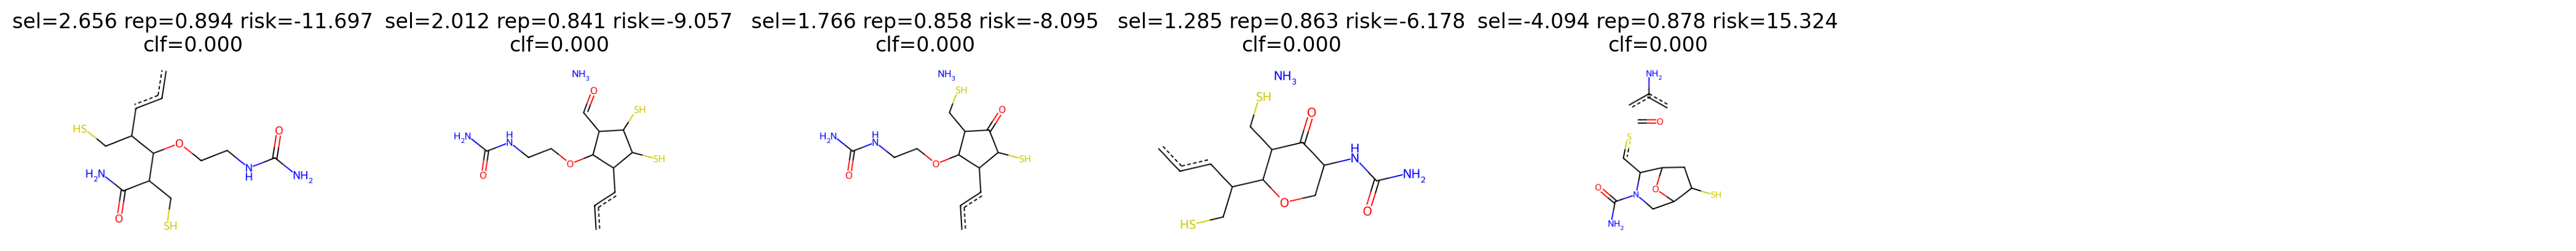

[graph 0] remaining_edges=1
search_phase=3/5 depth=4 step_time=2m 24.8s eta=2m 24.8s
tried=18045 generated=2565 partial_infeasible=2547 partial_feasible=18 lookahead_infeasible=4 viable=14 retained=5
best_score=0.000 best_selection_score=3.001 best_repulsion=0.864 best_risk=-13.041
repulsion_lambda=0.300 edge_risk_lambda=0.250 beam_limit=5


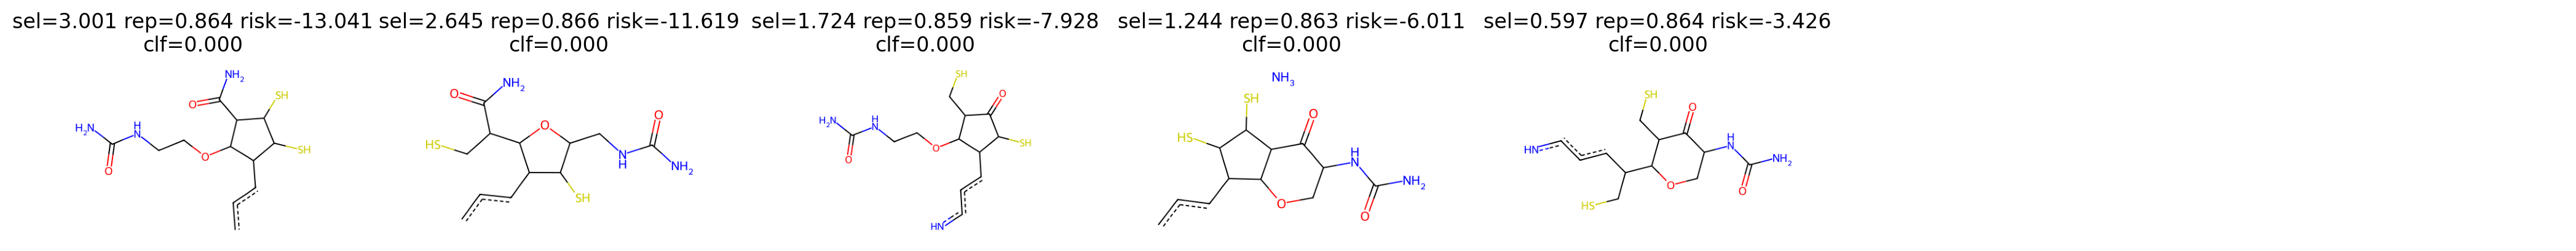

[graph 0] remaining_edges=0
search_phase=3/5 depth=5 step_time=2m 29.4s eta=0m 0.0s
tried=20595 generated=2550 partial_infeasible=2546 partial_feasible=4 viable=0 retained=0 final_infeasible=4
best_score=None best_risk=0.000
edge_risk_lambda=0.250 beam_limit=5
[graph 0] BACKTRACK no feasible candidates remain; 2 search phase(s) left
[edge_risk_fit] graphs=11850 training_set_size=20581 time=1m 12.2s
[graph 0] repair_fallback=3/4 rollback_steps=8 surgical_repairs=5 to_depth=0 beam_limit=7 edge_risk_training_set_size=20581 edge_risk_fit_time=1m 12.2s
[graph 0] surgical_removed_edges=['(9, 11),(2, 10),(4, 10),(2, 5),(7, 11),(5, 9),(1, 4),(8, 11)', '(9, 11),(5, 9),(7, 11),(8, 11),(4, 10),(4, 15),(1, 4),(5, 6)', '(9, 11),(7, 11),(1, 4),(4, 10),(4, 15),(8, 11),(1, 17),(1, 12)', '(9, 11),(4, 10),(4, 15),(7, 11),(1, 4),(6, 15),(8, 11),(1, 17)', '(9, 11),(5, 9),(7, 11),(8, 11),(5, 6),(6, 15),(4, 15),(2, 5)']
[graph 0] search_phase=4/5 beam_limit=7
[graph 0] remaining_edges=8
search_phase=4/5 dep

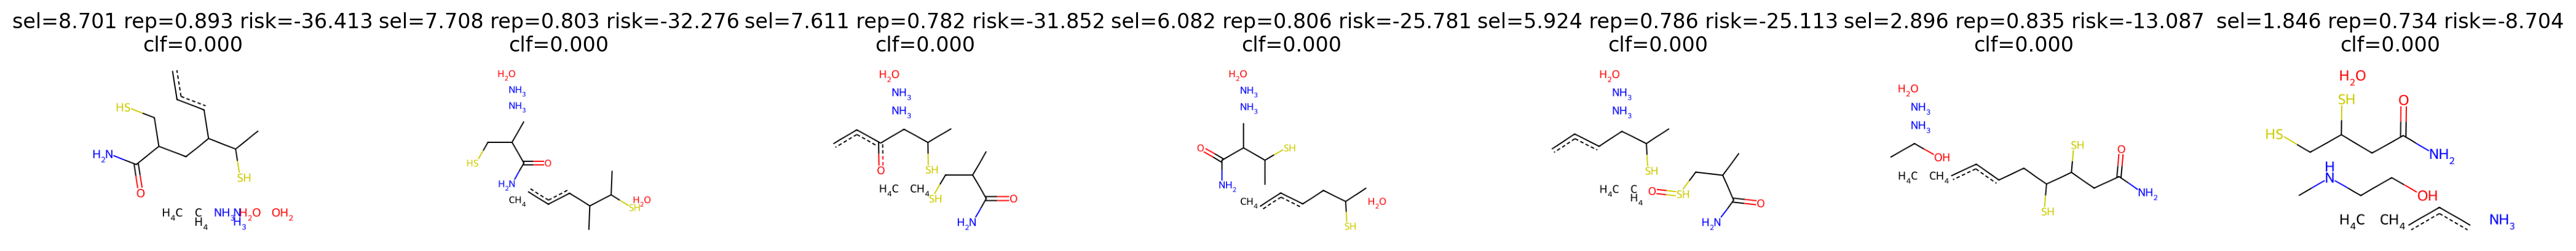

[graph 0] remaining_edges=7
search_phase=4/5 depth=2 step_time=3m 21.9s eta=23m 33.4s
tried=26982 generated=3717 partial_infeasible=3134 partial_feasible=583 lookahead_infeasible=163 viable=420 retained=7
best_score=0.000 best_selection_score=11.838 best_repulsion=0.885 best_risk=-48.946
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


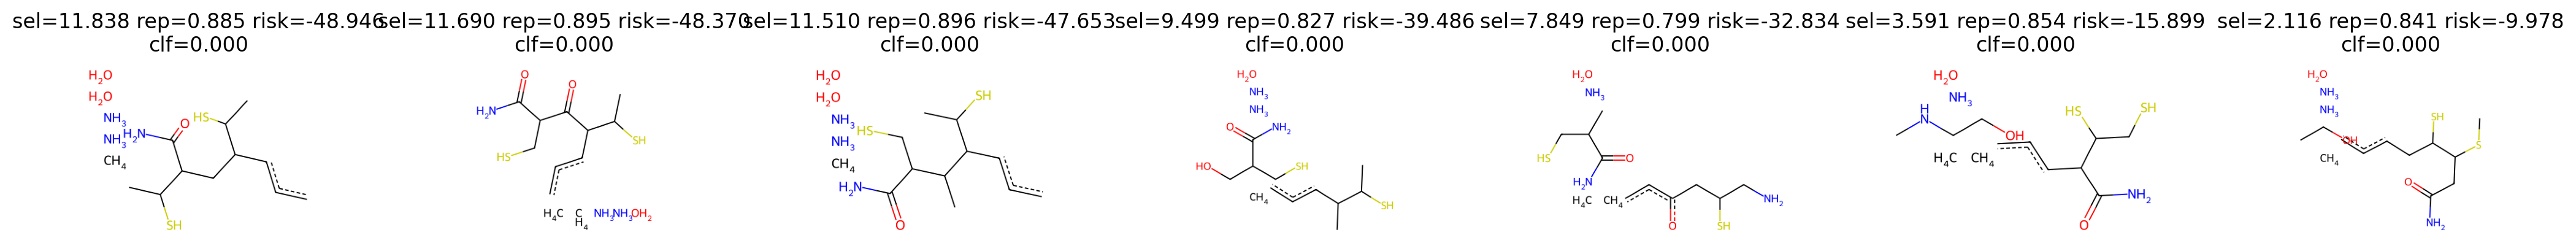

[graph 0] remaining_edges=6
search_phase=4/5 depth=3 step_time=3m 15.2s eta=19m 31.3s
tried=30678 generated=3696 partial_infeasible=3295 partial_feasible=401 lookahead_infeasible=150 viable=251 retained=7
best_score=0.000 best_selection_score=13.595 best_repulsion=0.898 best_risk=-55.996
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


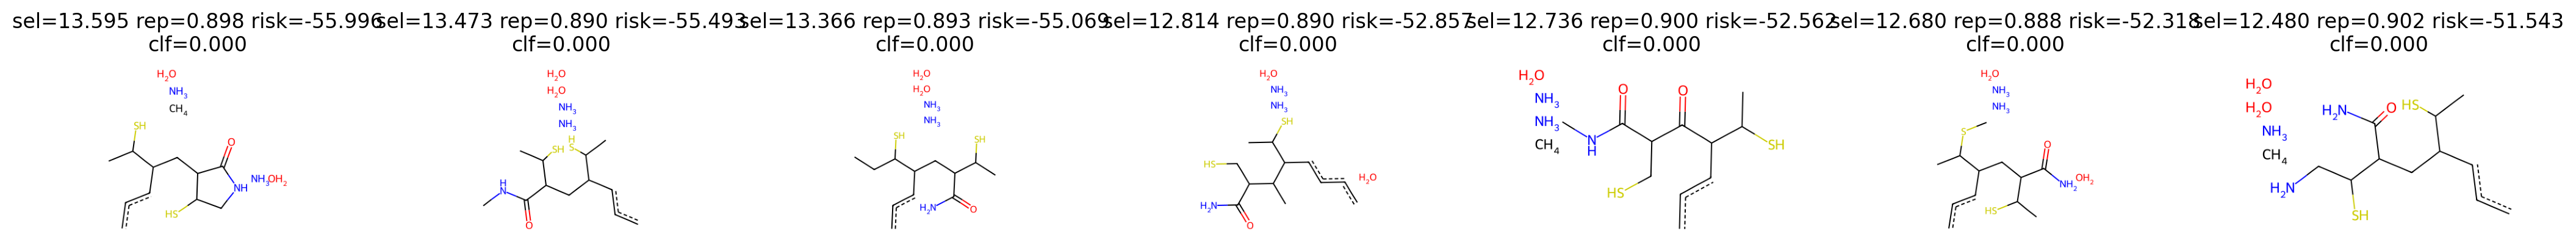

[graph 0] remaining_edges=5
search_phase=4/5 depth=4 step_time=3m 22.5s eta=16m 52.5s
tried=34353 generated=3675 partial_infeasible=3349 partial_feasible=326 lookahead_infeasible=158 viable=168 retained=7
best_score=0.000 best_selection_score=15.387 best_repulsion=0.903 best_risk=-63.171
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


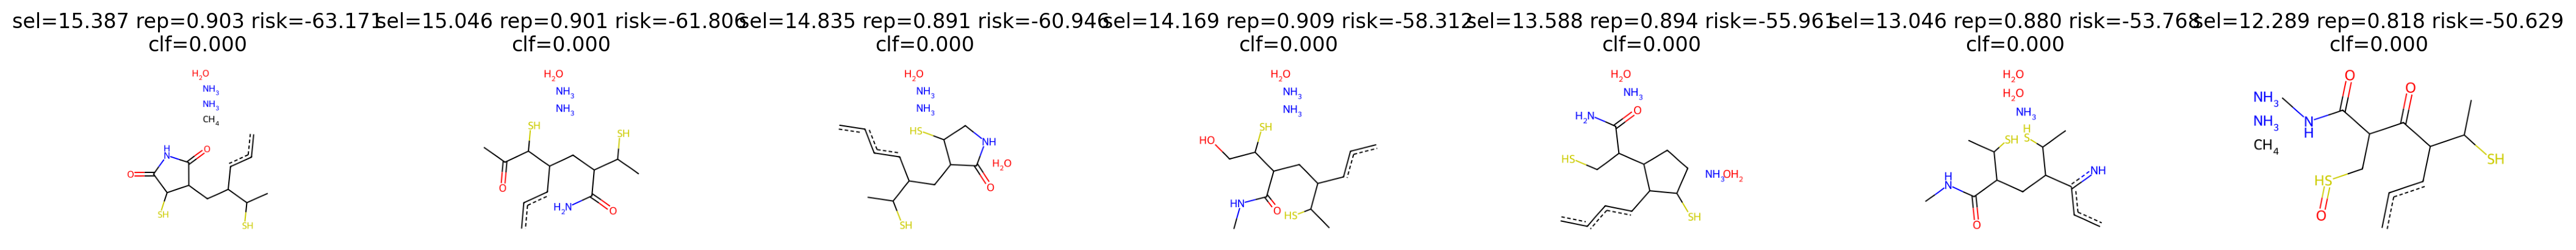

[graph 0] remaining_edges=4
search_phase=4/5 depth=5 step_time=2m 56.8s eta=11m 47.0s
tried=38007 generated=3654 partial_infeasible=3425 partial_feasible=229 lookahead_infeasible=36 viable=193 retained=7
best_score=0.000 best_selection_score=16.953 best_repulsion=0.909 best_risk=-69.448
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


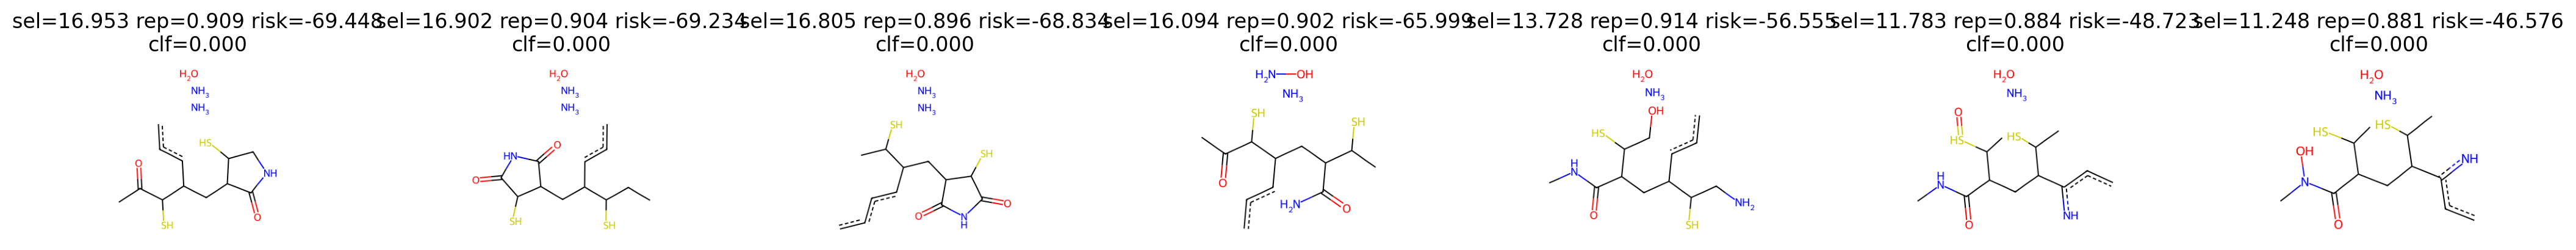

[graph 0] remaining_edges=3
search_phase=4/5 depth=6 step_time=2m 51.1s eta=8m 33.2s
tried=41640 generated=3633 partial_infeasible=3483 partial_feasible=150 lookahead_infeasible=2 viable=148 retained=7
best_score=0.000 best_selection_score=18.616 best_repulsion=0.909 best_risk=-76.101
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


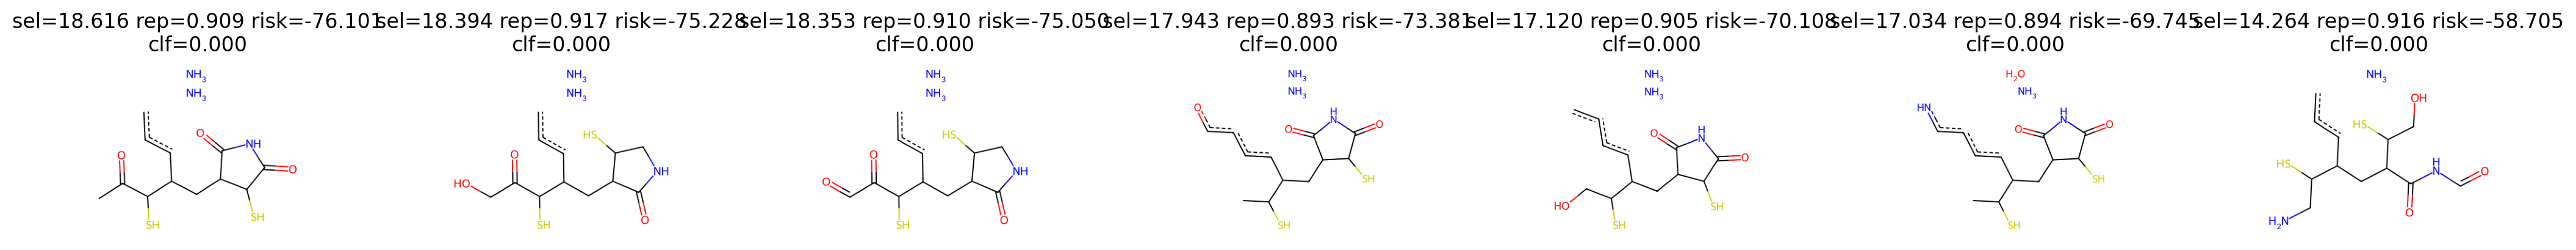

[graph 0] remaining_edges=2
search_phase=4/5 depth=7 step_time=2m 55.0s eta=5m 50.0s
tried=45252 generated=3612 partial_infeasible=3538 partial_feasible=74 lookahead_infeasible=4 viable=70 retained=7
best_score=0.000 best_selection_score=19.740 best_repulsion=0.912 best_risk=-80.603
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


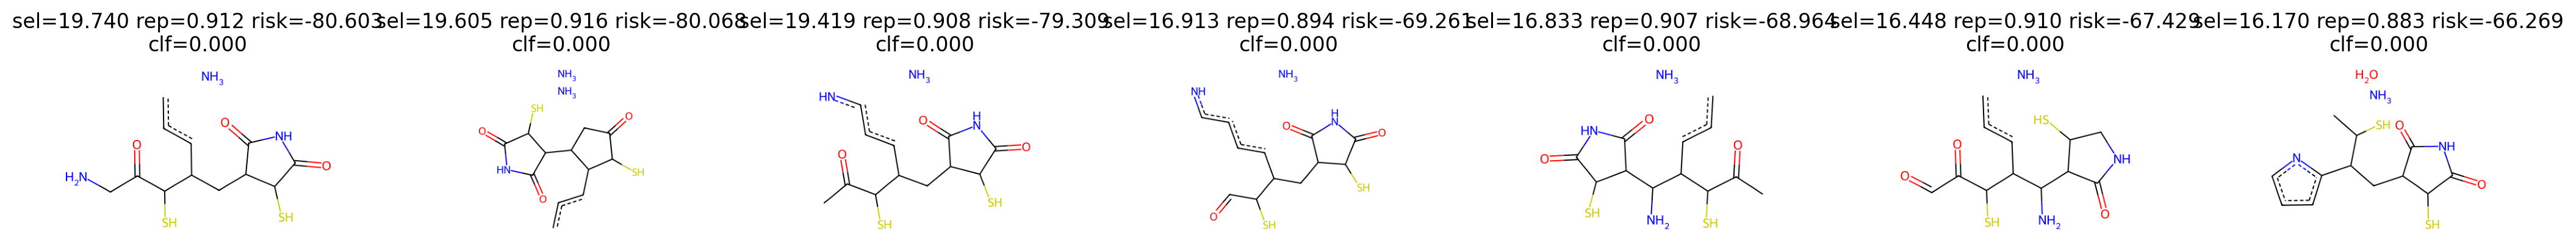

[graph 0] remaining_edges=1
search_phase=4/5 depth=8 step_time=3m 22.3s eta=3m 22.3s
tried=48843 generated=3591 partial_infeasible=3552 partial_feasible=39 lookahead_infeasible=1 viable=38 retained=7
best_score=0.000 best_selection_score=20.085 best_repulsion=0.912 best_risk=-81.983
repulsion_lambda=0.450 edge_risk_lambda=0.250 beam_limit=7


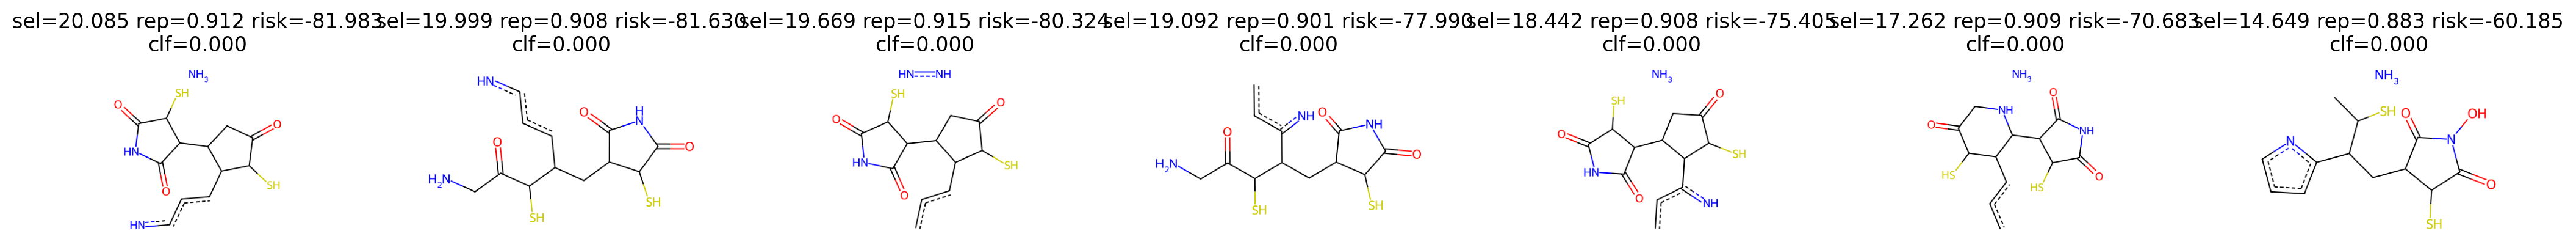

[graph 0] remaining_edges=0
search_phase=4/5 depth=9 step_time=3m 35.7s eta=0m 0.0s
tried=52413 generated=3570 partial_infeasible=3557 partial_feasible=13 viable=0 retained=0 final_infeasible=13
best_score=None best_risk=0.000
edge_risk_lambda=0.250 beam_limit=7
[graph 0] BACKTRACK no feasible candidates remain; 1 search phase(s) left
[edge_risk_fit] graphs=31811 training_set_size=52392 time=2m 47.2s
[graph 0] repair_fallback=4/4 rollback_steps=16 surgical_repairs=6 to_depth=0 beam_limit=11 edge_risk_training_set_size=52392 edge_risk_fit_time=2m 47.2s
[graph 0] surgical_removed_edges=['(4, 15),(4, 11),(2, 11),(15, 19),(1, 4),(2, 17),(6, 15),(5, 19),(2, 10),(1, 17),(3, 5),(5, 7),(3, 6),(1, 12),(6, 18),(16, 19)', '(4, 11),(2, 11),(4, 15),(1, 4),(2, 17),(1, 17),(1, 12),(2, 10),(15, 19),(0, 12),(5, 19),(0, 13),(5, 7),(6, 15),(3, 5),(14, 17)', '(4, 11),(2, 11),(1, 4),(1, 12),(4, 15),(0, 12),(2, 10),(2, 17),(1, 17),(15, 19),(5, 19),(9, 12),(5, 7),(6, 15),(0, 13),(3, 5)', '(1, 4),(1, 12),(4, 

In [ ]:
repair_results = repair_candidate_graphs(
    raw_samples,
    n_neighbors=7*3,
    graph_generator=graph_generator,
    model_filename=MODEL_FILENAME,
    notebook_data_root=NOTEBOOK_DATA_ROOT,
    random_seed=RANDOM_SEED,
)


In [ ]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

graph_generator.feasibility_rejection_mode = "fallback_unfiltered" #"fallback_unfiltered"  or "strict"

filtered_samples = graph_generator.sample(
    n_samples=N_SAMPLES,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=N_SAMPLES, title='Zing generation samples with feasibility filtering')


In [ ]:
repair_results = repair_candidate_graphs(
    filtered_samples,
    n_neighbors=7*1,
    graph_generator=graph_generator,
    model_filename=MODEL_FILENAME,
    notebook_data_root=NOTEBOOK_DATA_ROOT,
    random_seed=RANDOM_SEED,
)
